In [12]:
import pandas as pd
import numpy as np

In [13]:
filename = "/home/lacrio/cryoextremes-practicals/data/buoy/data_bouy.csv"

df_bouy = pd.read_csv(filename, sep='\t')
df_bouy['datetime'] = pd.to_datetime(df_bouy['datetime'])

df_bouy['datetime'] = df_bouy['datetime'] #+ pd.Timedelta(hours=3)

df_bouy = df_bouy.set_index('datetime')

df_bouy

,ws,tair,rh,press,SUp,sst
datetime,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.9,-0.081400
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.2,-0.079937
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.7,-0.072550
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.0,-0.085164
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.0,-0.081067
...,...,...,...,...,...,...
2024-12-13 19:00:00,5.977793,2.0,83.2,993.5,0.0,0.711133
2024-12-13 20:00:00,5.519941,1.9,84.5,994.0,0.0,0.726267
2024-12-13 21:00:00,6.610554,2.2,79.4,994.2,7.1,0.729700


In [14]:
from coare35vn import coare35vn

In [15]:
# =====================================================
# COARE 3.5
# =====================================================
A = coare35vn(
    df_bouy['ws'].values, df_bouy['tair'].values,  df_bouy['rh'].values, df_bouy['sst'].values,
    P=df_bouy['press'].values, Rs=df_bouy['SUp'].values, Rl=288,
    zu=1.8, zt=1.8, zq=1.8,
    lat=-62.109, zi=300,
    rain=np.zeros_like(df_bouy['ws']),
    jcool=1
)

/home/lacrio/cryoextremes-practicals/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


In [16]:
#df_bouy['H'] =  A[:, 2]
#df_bouy['LE'] = A[:, 3]

# Filtra directamente la matriz A antes o durante la asignación
df_bouy['H'] = np.where(np.abs(A[:, 2]) > 150, np.nan, A[:, 2])
df_bouy['LE'] = np.where(np.abs(A[:, 3]) > 150, np.nan, A[:, 3])


In [17]:
df_bouy = df_bouy.loc['2024-12-06':'2024-12-12']
df_bouy

,ws,tair,rh,press,SUp,sst,H,LE
datetime,,,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.90,-0.081400,13.362849,62.540917
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.20,-0.079937,11.982911,51.421519
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.70,-0.072550,10.135087,39.779440
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.00,-0.085164,4.196244,23.072508
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.00,-0.081067,7.897445,53.875356
...,...,...,...,...,...,...,...,...
2024-12-12 18:00:00,8.549993,2.9,90.3,990.7,176.50,0.666350,-35.571807,-12.611023
2024-12-12 19:00:00,9.810371,2.8,91.4,990.1,325.90,0.625117,-40.622898,-16.340625
2024-12-12 20:00:00,7.660012,3.2,91.0,989.9,265.20,0.689950,-35.011776,-15.188750


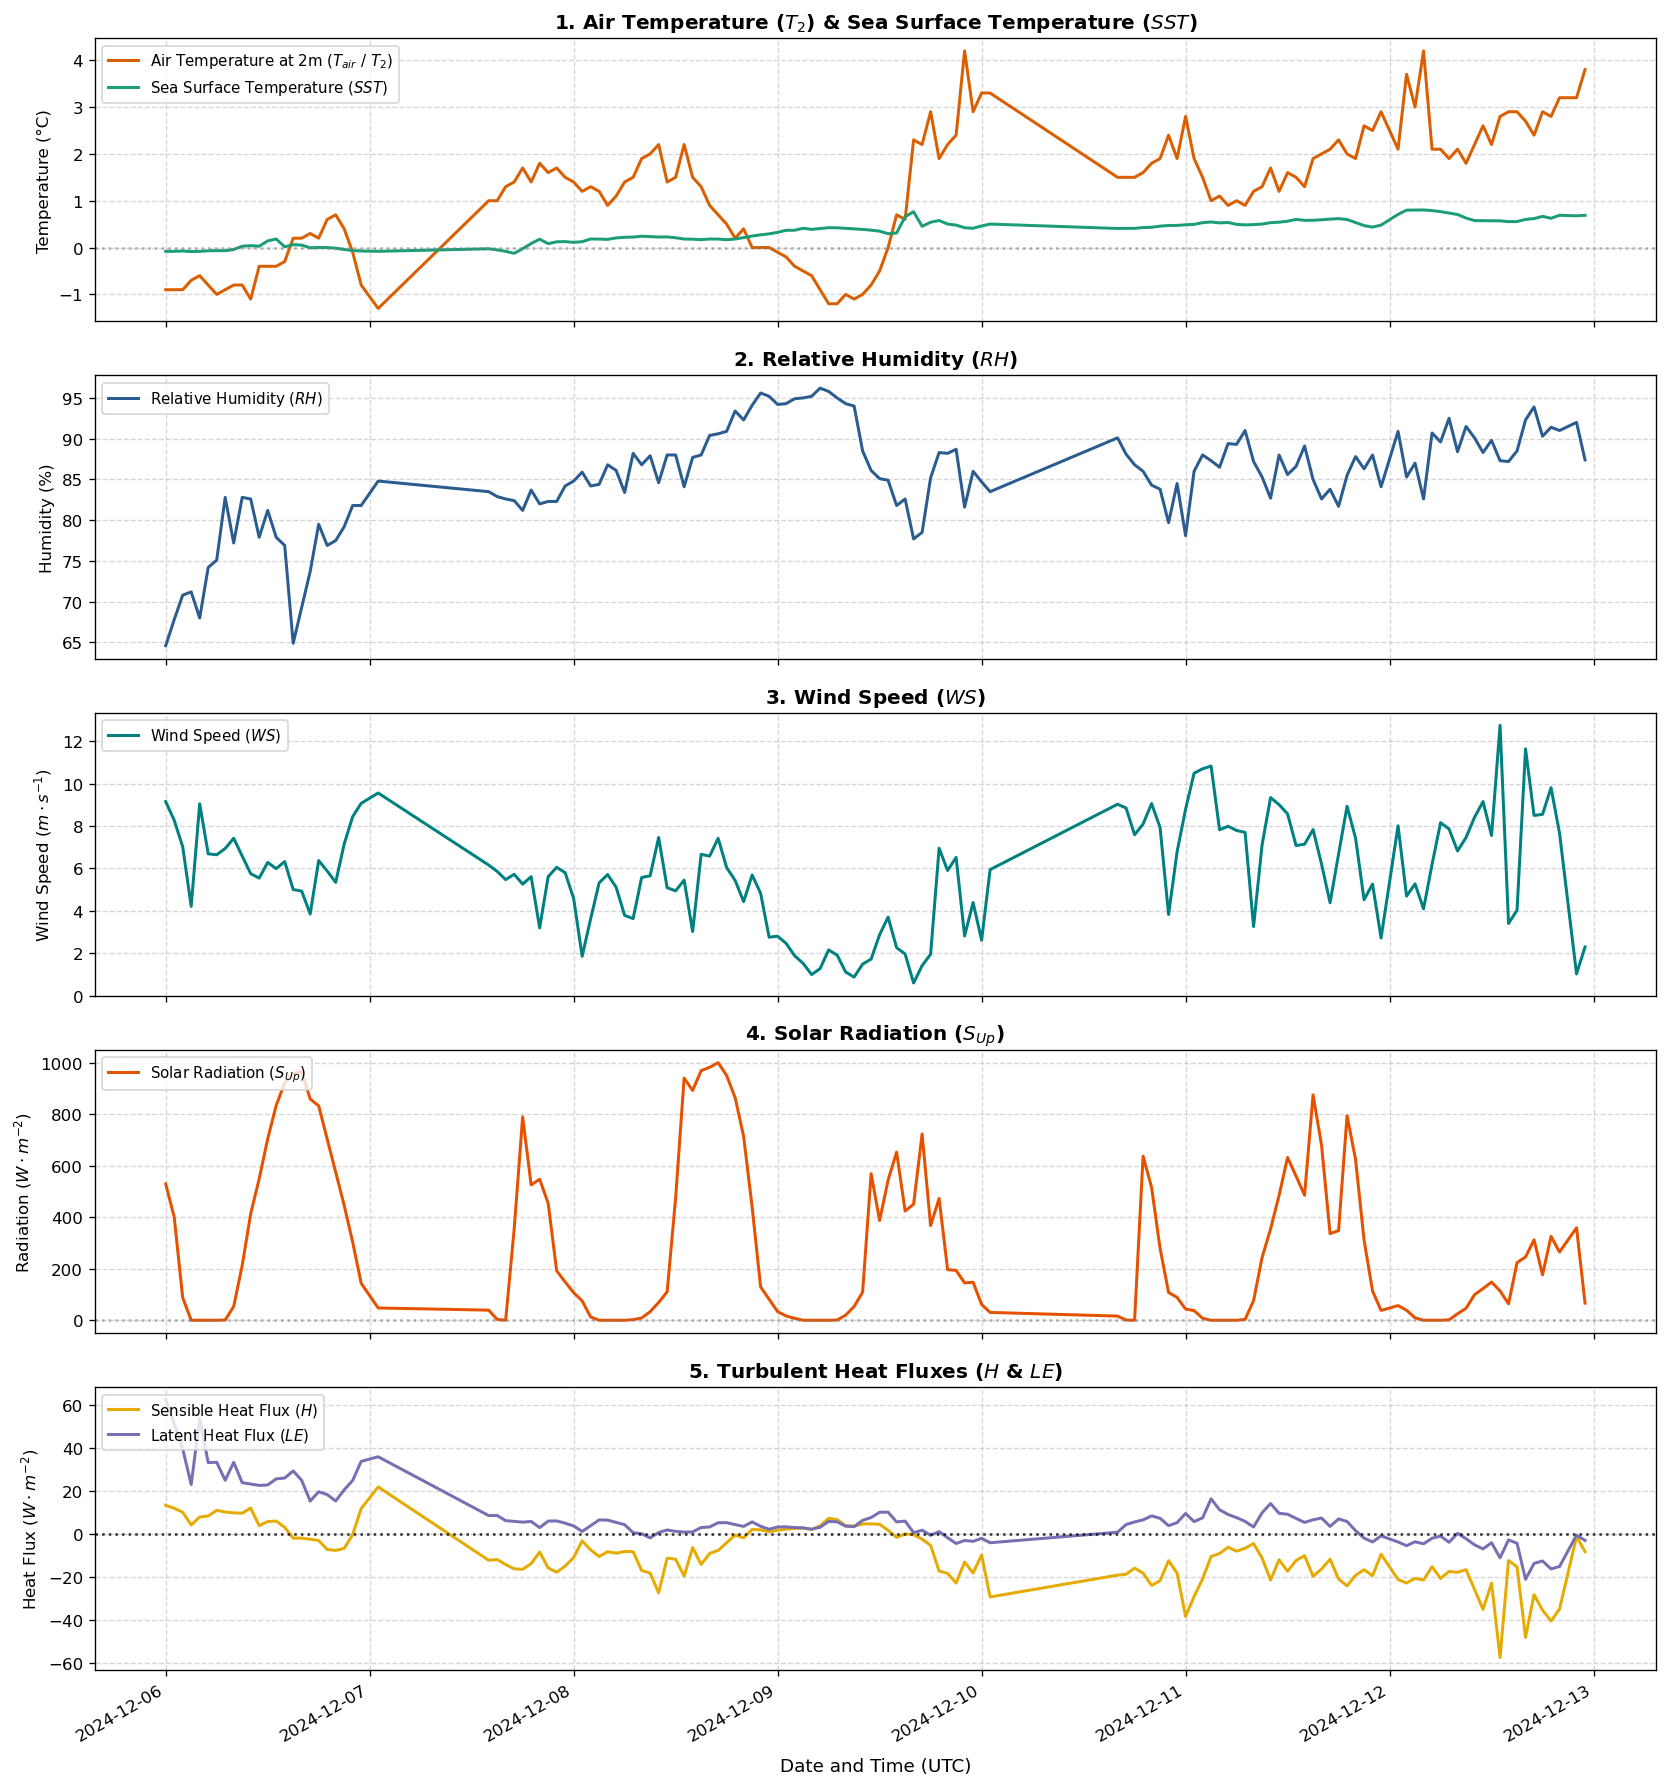

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copiar el DataFrame manteniendo todos los NaN
df_plot = df_bouy.copy()

# 2. Configurar la figura con 5 subplots
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(14, 15), sharex=True, dpi=120
)

# --- SUBPLOT 1: Temperaturas (tair / T2 y sst) ---
ax1.plot(
    df_plot.index,
    df_plot['tair'],
    label='Air Temperature at 2m ($T_{air}$ / $T_2$)',
    color='#d95f02',
    linewidth=1.8,
)
ax1.plot(
    df_plot.index,
    df_plot['sst'],
    label='Sea Surface Temperature ($SST$)',
    color='#1b9e77',
    linewidth=1.8,
)

ax1.set_title(
    '1. Air Temperature ($T_2$) & Sea Surface Temperature ($SST$)',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 2: Humedad Relativa (rh) ---
ax2.plot(
    df_plot.index,
    df_plot['rh'],
    label='Relative Humidity ($RH$)',
    color='#2b5c8f',
    linewidth=1.8,
)

ax2.set_title('2. Relative Humidity ($RH$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 3: Velocidad del Viento (ws) ---
ax3.plot(
    df_plot.index,
    df_plot['ws'],
    label='Wind Speed ($WS$)',
    color='#008080',
    linewidth=1.8,
)

ax3.set_title('3. Wind Speed ($WS$)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Wind Speed ($m \\cdot s^{-1}$)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 4: Radiación Solar Incidente/Reflejada (SUp) ---
ax4.plot(
    df_plot.index,
    df_plot['SUp'],
    label='Solar Radiation ($S_{Up}$)',
    color='#e65100',
    linewidth=1.8,
)

ax4.set_title('4. Solar Radiation ($S_{Up}$)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Radiation ($W \\cdot m^{-2}$)', fontsize=10)
ax4.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 5: Flujos Turbulentos de Calor (H & LE) ---
ax5.plot(
    df_plot.index,
    df_plot['H'],
    label='Sensible Heat Flux ($H$)',
    color='#e6ab02',
    linewidth=1.8,
)
ax5.plot(
    df_plot.index,
    df_plot['LE'],
    label='Latent Heat Flux ($LE$)',
    color='#7570b3',
    linewidth=1.8,
)

ax5.set_title(
    '5. Turbulent Heat Fluxes ($H$ & $LE$)',
    fontsize=12,
    fontweight='bold',
)
ax5.set_xlabel('Date and Time (UTC)', fontsize=11, labelpad=8)
ax5.set_ylabel('Heat Flux ($W \\cdot m^{-2}$)', fontsize=10)
ax5.axhline(0, color='black', linestyle=':', alpha=0.8)
ax5.grid(True, linestyle='--', alpha=0.5)
ax5.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# Formato final
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

In [19]:
# 1. Asegurar que el índice es de tipo DatetimeIndex
df_bouy.index = pd.to_datetime(df_bouy.index)

# 2. Generar una secuencia completa hora a hora desde el inicio hasta el final
full_time_range = pd.date_range(
    start=df_bouy.index.min(), end=df_bouy.index.max(), freq="1h"
)

# 3. Reindexar el DataFrame (las horas faltantes se completarán automáticamente con NaN)
df_bouy = df_bouy.reindex(full_time_range)

# 4. Asignar el nombre al índice
df_bouy.index.name = "datetime"

# Mostrar el DataFrame resultante
df_bouy

,ws,tair,rh,press,SUp,sst,H,LE
datetime,,,,,,,,
2024-12-06 00:00:00,9.151888,-0.9,64.6,1013.4,529.90,-0.081400,13.362849,62.540917
2024-12-06 01:00:00,8.272195,-0.9,67.8,1013.3,401.20,-0.079937,11.982911,51.421519
2024-12-06 02:00:00,7.022106,-0.9,70.8,1013.6,87.70,-0.072550,10.135087,39.779440
2024-12-06 03:00:00,4.208119,-0.7,71.2,1013.8,0.00,-0.085164,4.196244,23.072508
2024-12-06 04:00:00,9.049000,-0.6,68.0,1013.6,0.00,-0.081067,7.897445,53.875356
...,...,...,...,...,...,...,...,...
2024-12-12 19:00:00,9.810371,2.8,91.4,990.1,325.90,0.625117,-40.622898,-16.340625
2024-12-12 20:00:00,7.660012,3.2,91.0,989.9,265.20,0.689950,-35.011776,-15.188750
2024-12-12 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
df_bouy.index.max()

Timestamp('2024-12-12 23:00:00')

In [21]:
df_bouy.to_csv('data/pross/data_buoy_full_time.csv', sep='\t')

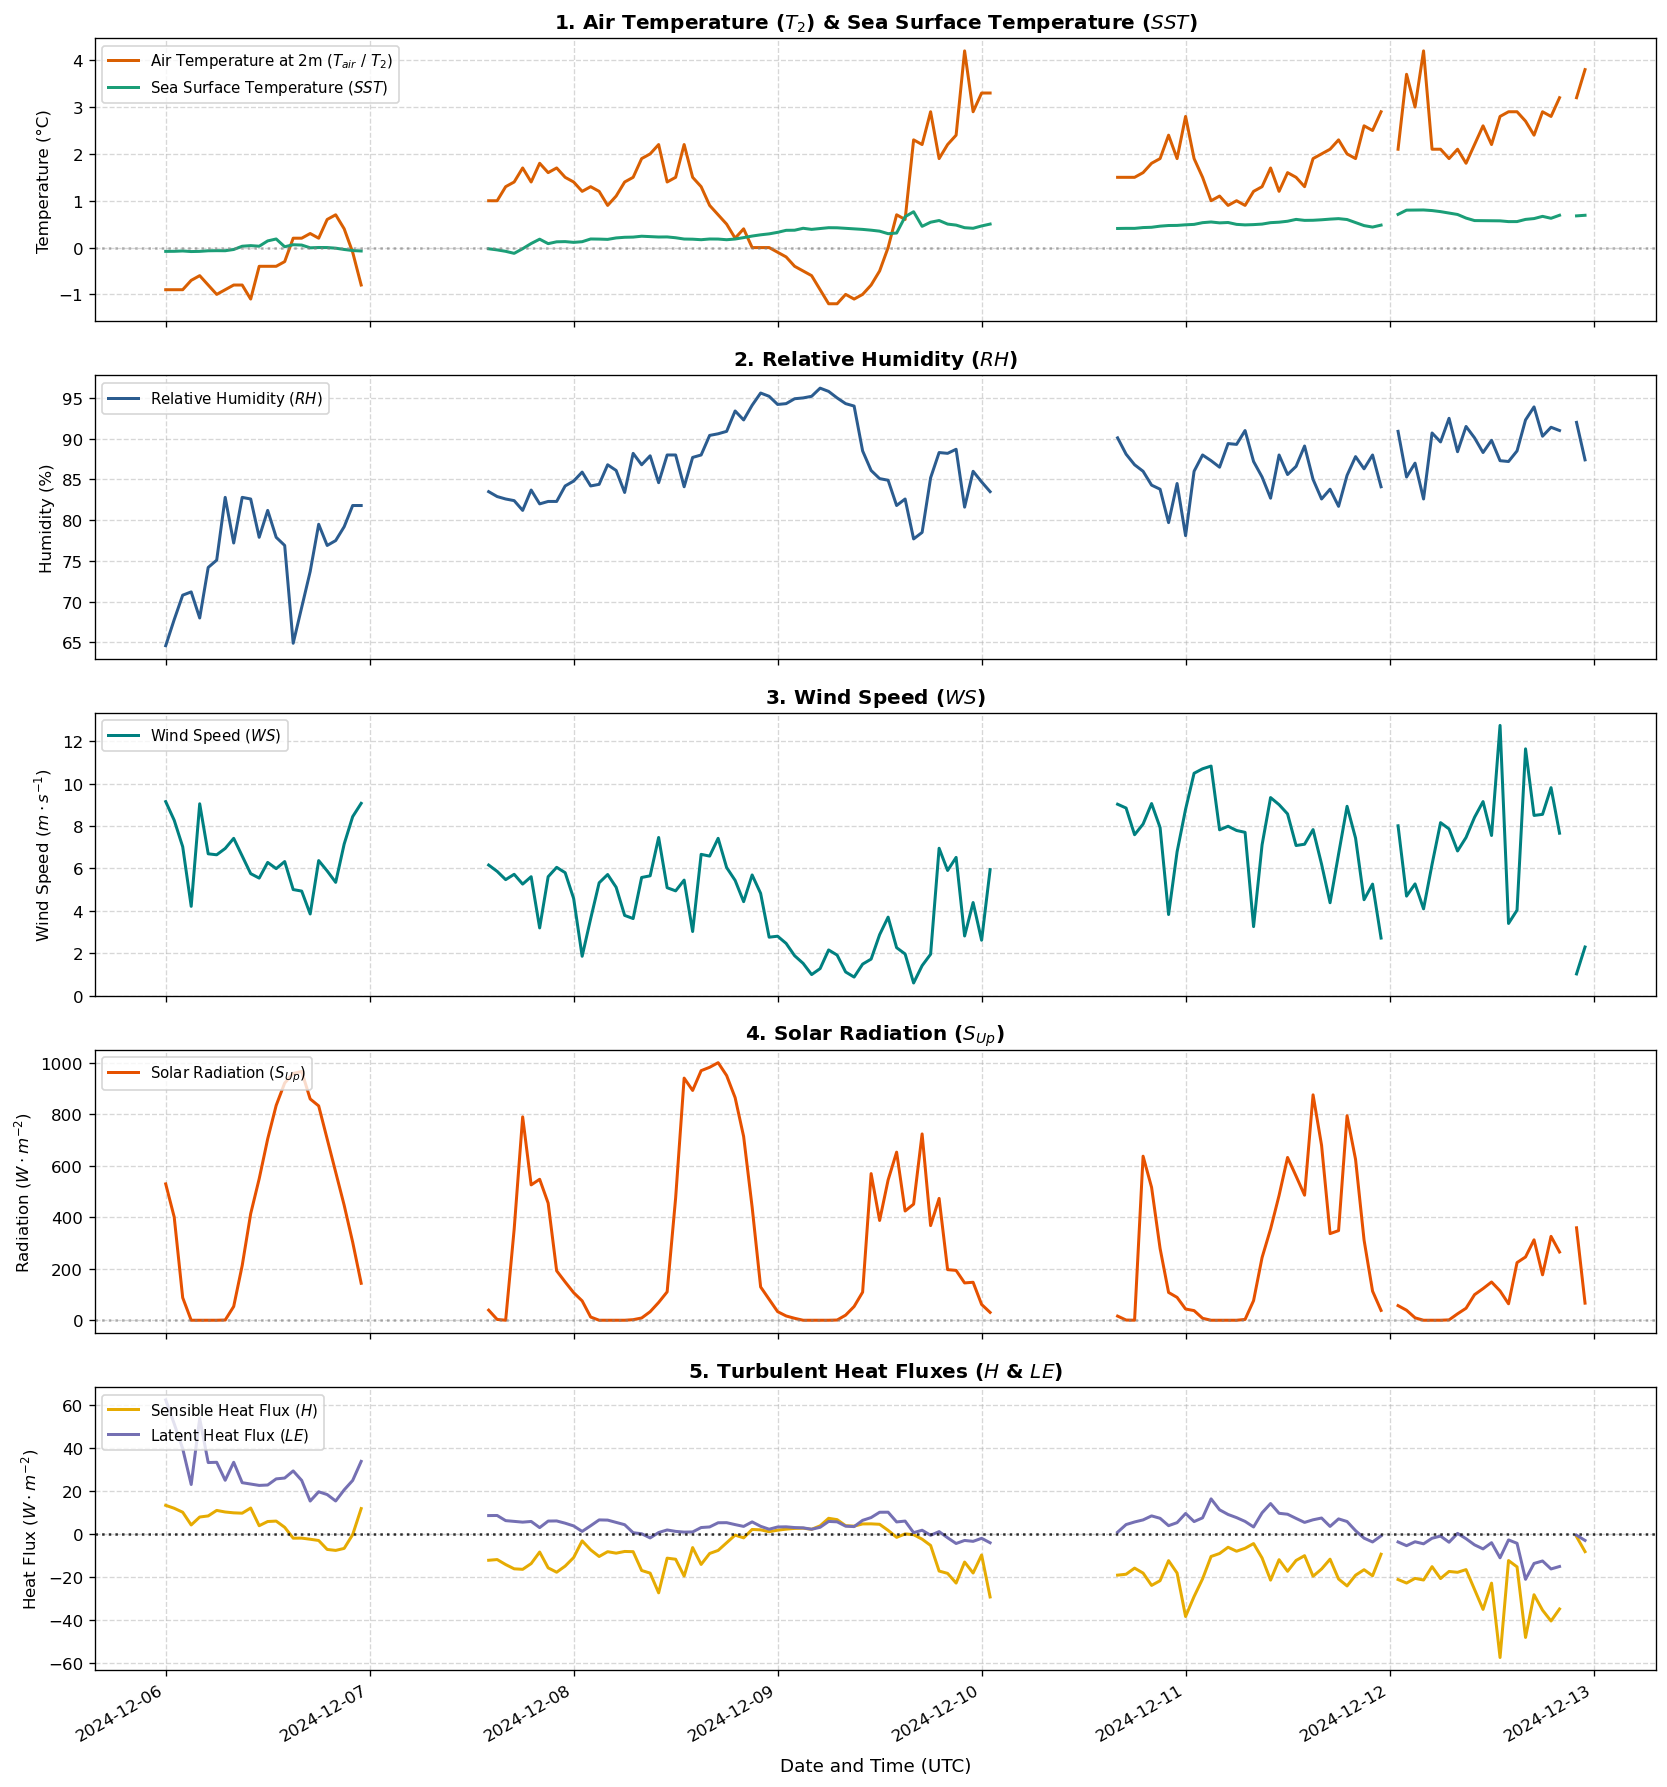

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Copiar el DataFrame manteniendo todos los NaN
df_plot = df_bouy.copy()

# 2. Configurar la figura con 5 subplots
fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(
    5, 1, figsize=(14, 15), sharex=True, dpi=120
)

# --- SUBPLOT 1: Temperaturas (tair / T2 y sst) ---
ax1.plot(
    df_plot.index,
    df_plot['tair'],
    label='Air Temperature at 2m ($T_{air}$ / $T_2$)',
    color='#d95f02',
    linewidth=1.8,
)
ax1.plot(
    df_plot.index,
    df_plot['sst'],
    label='Sea Surface Temperature ($SST$)',
    color='#1b9e77',
    linewidth=1.8,
)

ax1.set_title(
    '1. Air Temperature ($T_2$) & Sea Surface Temperature ($SST$)',
    fontsize=12,
    fontweight='bold',
)
ax1.set_ylabel('Temperature (°C)', fontsize=10)
ax1.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 2: Humedad Relativa (rh) ---
ax2.plot(
    df_plot.index,
    df_plot['rh'],
    label='Relative Humidity ($RH$)',
    color='#2b5c8f',
    linewidth=1.8,
)

ax2.set_title('2. Relative Humidity ($RH$)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Humidity (%)', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 3: Velocidad del Viento (ws) ---
ax3.plot(
    df_plot.index,
    df_plot['ws'],
    label='Wind Speed ($WS$)',
    color='#008080',
    linewidth=1.8,
)

ax3.set_title('3. Wind Speed ($WS$)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Wind Speed ($m \\cdot s^{-1}$)', fontsize=10)
ax3.grid(True, linestyle='--', alpha=0.5)
ax3.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 4: Radiación Solar Incidente/Reflejada (SUp) ---
ax4.plot(
    df_plot.index,
    df_plot['SUp'],
    label='Solar Radiation ($S_{Up}$)',
    color='#e65100',
    linewidth=1.8,
)

ax4.set_title('4. Solar Radiation ($S_{Up}$)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Radiation ($W \\cdot m^{-2}$)', fontsize=10)
ax4.axhline(0, color='gray', linestyle=':', alpha=0.6)
ax4.grid(True, linestyle='--', alpha=0.5)
ax4.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# --- SUBPLOT 5: Flujos Turbulentos de Calor (H & LE) ---
ax5.plot(
    df_plot.index,
    df_plot['H'],
    label='Sensible Heat Flux ($H$)',
    color='#e6ab02',
    linewidth=1.8,
)
ax5.plot(
    df_plot.index,
    df_plot['LE'],
    label='Latent Heat Flux ($LE$)',
    color='#7570b3',
    linewidth=1.8,
)

ax5.set_title(
    '5. Turbulent Heat Fluxes ($H$ & $LE$)',
    fontsize=12,
    fontweight='bold',
)
ax5.set_xlabel('Date and Time (UTC)', fontsize=11, labelpad=8)
ax5.set_ylabel('Heat Flux ($W \\cdot m^{-2}$)', fontsize=10)
ax5.axhline(0, color='black', linestyle=':', alpha=0.8)
ax5.grid(True, linestyle='--', alpha=0.5)
ax5.legend(loc='upper left', frameon=True, facecolor='white', fontsize=9)

# Formato final
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()